In [1]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Tplus Computer\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt

In [2]:
import osmnx as ox
# Tải mạng lưới đường bộ của Hà Nội
G = ox.graph_from_place('Hanoi, Vietnam', network_type='drive')
# G bây giờ là một đồ thị networkx

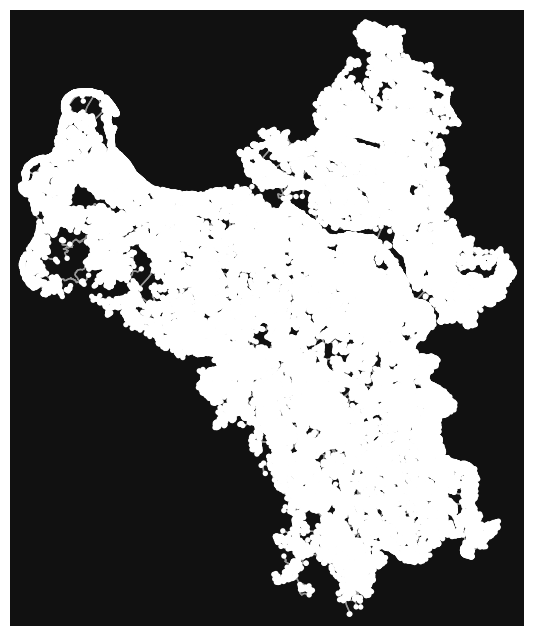

In [5]:
ox.plot_graph(G)
plt.show()  # <-- Dòng này sẽ mở 1 cửa sổ mới để hiển thị ảnh

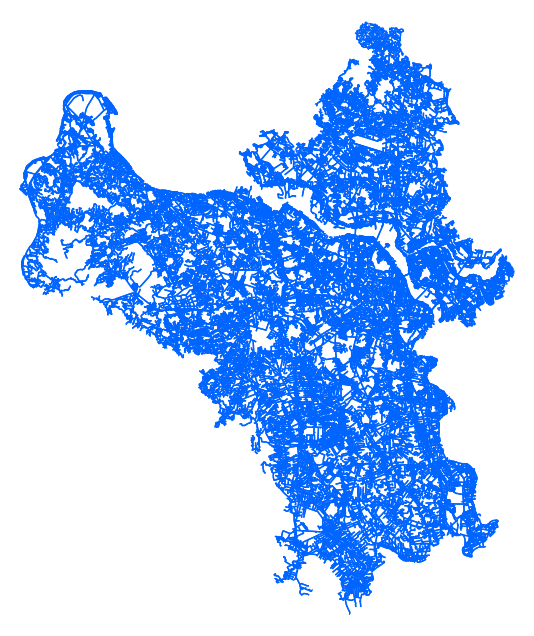

In [6]:
ox.plot_graph(G, 
              node_size=0,           # Vẫn ẩn các nút giao lộ
              edge_color='#0064FF',  # Đổi màu đường thành màu xanh
              bgcolor='white')       # Nền trắng

plt.show()

Đang tải ranh giới Hà Nội...
Đã tải ranh giới.


C:\Users\Tplus Computer\AppData\Local\Temp\ipykernel_26304\1751172734.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hanoi_polygon = gdf_place.unary_union # Kết hợp các đa giác nếu là MultiPolygon


Đã tạo 3153 ô lưới.


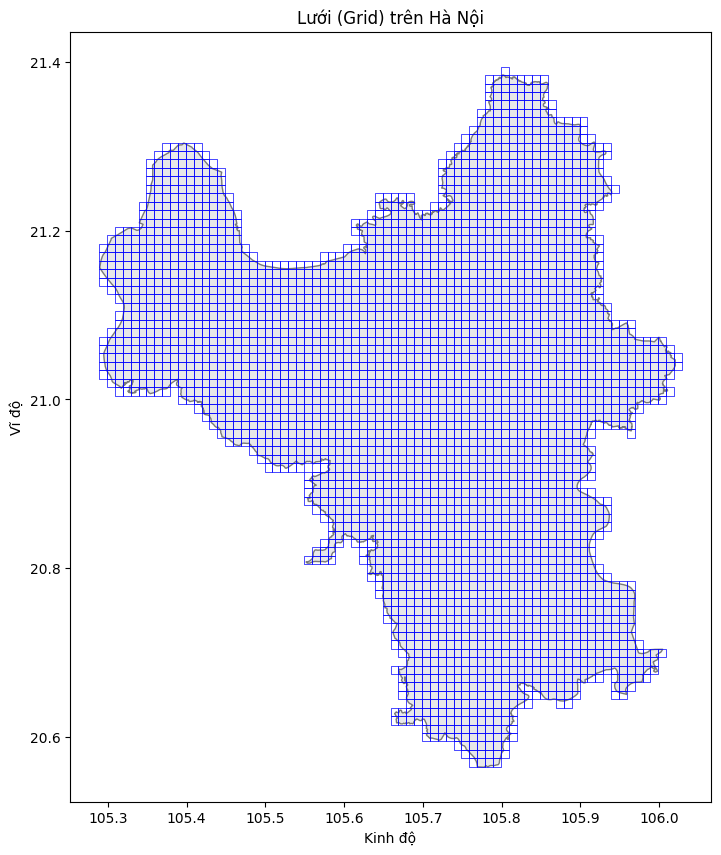

In [7]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# 1. Lấy ranh giới hành chính của Hà Nội
print("Đang tải ranh giới Hà Nội...")
# Sử dụng 'administrative' để lấy ranh giới hành chính
place_name = "Hanoi, Vietnam"
gdf_place = ox.geocode_to_gdf(place_name)

# Kiểm tra xem có dữ liệu không
if gdf_place.empty:
    print("Không tìm thấy ranh giới cho Hà Nội.")
else:
    # Lấy hình dạng đa giác của Hà Nội (có thể là một MultiPolygon)
    hanoi_polygon = gdf_place.unary_union # Kết hợp các đa giác nếu là MultiPolygon
    print("Đã tải ranh giới.")

    # 2. Xác định phạm vi (bounding box) của Hà Nội
    minx, miny, maxx, maxy = hanoi_polygon.bounds

    # 3. Tạo lưới các ô vuông
    # Kích thước ô vuông (ví dụ: 0.01 độ kinh/vĩ độ, tương đương khoảng 1km x 1km gần xích đạo)
    # Lưu ý: Kích thước này không chính xác 1km ở vĩ độ của Hà Nội, nhưng đủ cho mục đích minh họa
    cell_size_degree = 0.01  # Khoảng 1km

    grid_cells = []
    # Đi qua từng hàng và cột trong phạm vi
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            # Tạo một ô vuông (polygon)
            cell = Polygon([(x, y), (x + cell_size_degree, y),
                            (x + cell_size_degree, y + cell_size_degree),
                            (x, y + cell_size_degree)])
            
            # Chỉ thêm ô nếu nó nằm trong ranh giới Hà Nội
            if hanoi_polygon.intersects(cell):
                grid_cells.append(cell)
            
            y += cell_size_degree
        x += cell_size_degree

    # Tạo GeoDataFrame từ các ô lưới
    gdf_grid = gpd.GeoDataFrame(geometry=grid_cells, crs=gdf_place.crs)
    print(f"Đã tạo {len(grid_cells)} ô lưới.")

    # 4. Trực quan hóa
    fig, ax = plt.subplots(figsize=(10, 10))

    # Vẽ ranh giới Hà Nội
    gdf_place.plot(ax=ax, facecolor='lightgray', edgecolor='black', alpha=0.5)

    # Vẽ các ô lưới
    gdf_grid.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=0.5)

    ax.set_title("Lưới (Grid) trên Hà Nội")
    ax.set_xlabel("Kinh độ")
    ax.set_ylabel("Vĩ độ")
    plt.show()

# Đây là ảnh của grid Hà Nội